## Calibrate NCHR BPR Data

Loads the multi-year raw frequency dataset from `out/NCHR_BPR_raw.parquet/`,
then applies Paroscientific and Platinum RTD calibration to produce physical
pressure (dbar) and temperature (°C) time-series.

> **Kernel:** select the `bpr-nchr` conda environment.

In [1]:
import pandas as pd
import numpy as np
from src.calibrateBPRData import CalibrationCoefficients as CCD
from src.build_parquet import load_dataset

pd.set_option('display.precision', 15)

In [18]:
# Sensor serial numbers / IDs for the NCHR deployment
paroSensorID = 93996   # Paroscientific pressure + seawater-temp sensor
loggerID     = 0xB9    # BPR logger ID
TempSensorID = 0x98    # Platinum RTD housing-temperature sensor

ccd = CCD()
CP_SF = ccd.getParoCoeffs(paroSensorID)      # Paroscientific calibration coefficients
CT_Ti = ccd.getPlatinumCoeffs(TempSensorID)  # Platinum RTD calibration coefficients

print('Paroscientific coefficients:', CP_SF)
print('Platinum coefficients      :', CT_Ti)

133
Done!!!!!!!!!!!
=======  1
129
81 {'a': -2.93721e-06, 'b': 39.9656}
=======  2
130
82 {'a': -2.93721e-06, 'b': 39.8926}
=======  3
131
83 {'a': -2.93721e-06, 'b': 39.7979}
=======  4
132
84 {'a': -2.97409e-06, 'b': 40.341}
=======  5
133
85 {'a': -2.96621e-06, 'b': 40.2744}
=======  6
134
86 {'a': -2.93721e-06, 'b': 40.0144}
=======  7
135
87 {'a': -2.90214e-06, 'b': 39.5188}
=======  8
136
88 {'a': -2.93721e-06, 'b': 39.8746}
=======  9
137
89 {'a': -2.93721e-06, 'b': 39.9678}
=======  10
138
8A {'a': -2.90639e-06, 'b': 39.5433}
=======  11
139
8B {'a': -2.93721e-06, 'b': 39.9588}
=======  12
140
8C {'a': -2.93721e-06, 'b': 39.9603}
=======  13
145
91 {'a': -2.9556e-06, 'b': 40.1569}
=======  14
146
92 {'a': -2.95416e-06, 'b': 40.1418}
=======  15
147
93 {'a': -2.95961e-06, 'b': 40.2174}
=======  16
148
94 {'a': -2.95027e-06, 'b': 40.0112}
=======  17
149
95 {'a': -2.95183e-06, 'b': 40.1531}
=======  18
150
96 {'a': -2.95083e-06, 'b': 40.0678}
=======  19
151
97 {'a': -2.94964e-06

### Load the raw frequency dataset

In [17]:
# Load full dataset — restrict with date_from / date_to for a subset
df = load_dataset()
# df = load_dataset(date_from='2025-01-01', date_to='2025-02-01')

print(f'Rows loaded : {len(df):,}')
print(f'Date range  : {df.index.min()}  →  {df.index.max()}')
df.head()

Rows loaded : 4,060,813
Date range  : 2022-05-31 00:00:00.702000  →  2026-03-24 23:59:59.055000


,ppc_time,t_housing_counts,xFT,xFP,X_period_us,T_period_us,year,month
dmas_time,,,,,,,,
2022-05-31 00:00:00.702,2022-05-31 00:00:03,12933627,702069311,1789632654,5.817316247752110,28.333626454225154,2022,5
2022-05-31 00:00:01.703,2022-05-31 00:00:04,12933778,702069307,1789632689,5.817316243095497,28.333626617206605,2022,5
2022-05-31 00:00:02.703,2022-05-31 00:00:05,12933741,702069312,1789632606,5.817316248916264,28.333626230707736,2022,5
2022-05-31 00:00:03.703,2022-05-31 00:00:06,12933592,702069307,1789632611,5.817316243095497,28.333626253990801,2022,5
2022-05-31 00:00:04.703,2022-05-31 00:00:07,12933806,702069309,1789632620,5.817316245423804,28.333626295900316,2022,5


In [4]:
df.dtypes

ppc_time            datetime64[us]
t_housing_counts             Int32
xFT                          Int64
xFP                          Int64
X_period_us                float64
T_period_us                float64
year                         int32
month                        int32
dtype: object

### Modify your calibration coefficients

In [19]:
# current coefficients
CP_SF

{'U0': 5.817758,
 'Y1': -4013.087,
 'Y2': -10199.75,
 'C1': -26728.97,
 'C2': -478.2363,
 'C3': 78896.04,
 'D1': 0.040344,
 'T1': 29.96666,
 'T2': 0.835539,
 'T3': 58.79293,
 'T4': 183.2334}

In [10]:
CP_SF['U0'] = 5.81266
CP_SF['D1'] = 0.14432

### Calibrate: counts / periods → physical units

In [ ]:
# Housing temperature (Platinum RTD)
df['T_Housing'] = df['t_housing_counts'].apply(
    lambda x: ccd.calibratePlatinum(x, Coeffs=CT_Ti) if pd.notna(x) else np.nan
)

# Seawater temperature (Paroscientific Type-II)
df['T_SF'] = df['xFT'].apply(
    lambda x: ccd.calibrateParoT(int(x), Coeffs=CP_SF) if pd.notna(x) else np.nan
)

# Pressure in dbar (temperature-compensated)
df['P_SF'] = [
    ccd.calibrateParoP(int(xFP), Coeffs=CP_SF, Temp=T_SF)
    if pd.notna(xFP) and pd.notna(T_SF) else np.nan
    for xFP, T_SF in zip(df['xFP'], df['T_SF'])
]



KeyboardInterrupt: 

,T_Housing,T_SF,P_SF
dmas_time,,,
2022-05-31 00:00:00.702,1.995617512919999,1.770799772519996,2195.501126017128627
2022-05-31 00:00:01.703,1.995172660879994,1.770818417949177,2195.500881318553638
2022-05-31 00:00:02.703,1.995281664359993,1.770795111162632,2195.501455684324355
2022-05-31 00:00:03.703,1.995720624319993,1.770818417949177,2195.501414883362031
2022-05-31 00:00:04.703,1.995090171759998,1.770809095234642,2195.501355957421310
...,...,...,...
2022-06-30 03:46:35.581,1.938249275999993,1.710045954168988,2195.197050465463235
2022-06-30 03:46:36.582,1.938549772079995,1.710069262756977,2195.196688152737806
2022-06-30 03:46:37.582,1.938072513599998,1.710059939321864,2195.197142264562444


In [21]:
df[['T_Housing', 'T_SF', 'P_SF']].describe()

,T_Housing,T_SF,P_SF
count,4.060813000000000e+06,4.060813000000000e+06,4.060813000000000e+06
mean,1.930903897373431e+00,1.702144094804612e+00,2.195267026879394e+03
std,2.126677274683915e-02,2.140881644354542e-02,7.778529101880538e-01
min,1.880839794520000e+00,1.653487960853889e+00,2.193274119184697e+03
25%,1.916324846319995e+00,1.687636757926784e+00,2.194715177867592e+03
50%,1.930589571999995e+00,1.701799332358192e+00,2.195331136459875e+03
75%,1.942258836439997e+00,1.713122681807793e+00,2.195857333345780e+03
max,2.020561633599996e+00,1.794236727815677e+00,2.196984220682743e+03


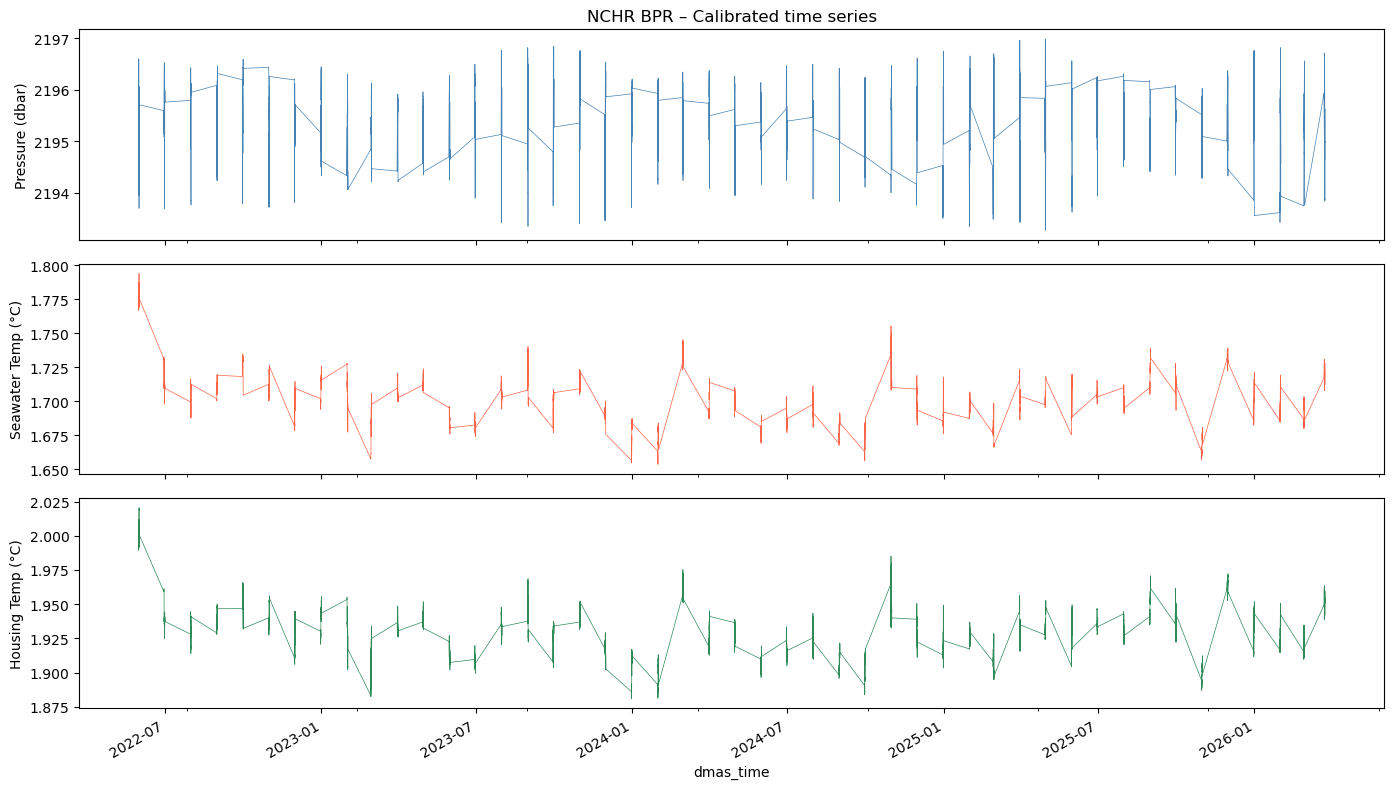

In [22]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

df['P_SF'].plot(ax=axes[0], lw=0.5, color='steelblue')
axes[0].set_ylabel('Pressure (dbar)')

df['T_SF'].plot(ax=axes[1], lw=0.5, color='tomato')
axes[1].set_ylabel('Seawater Temp (°C)')

df['T_Housing'].plot(ax=axes[2], lw=0.5, color='seagreen')
axes[2].set_ylabel('Housing Temp (°C)')

axes[0].set_title('NCHR BPR – Calibrated time series')
plt.tight_layout()
plt.show()

<Axes: xlabel='dmas_time'>

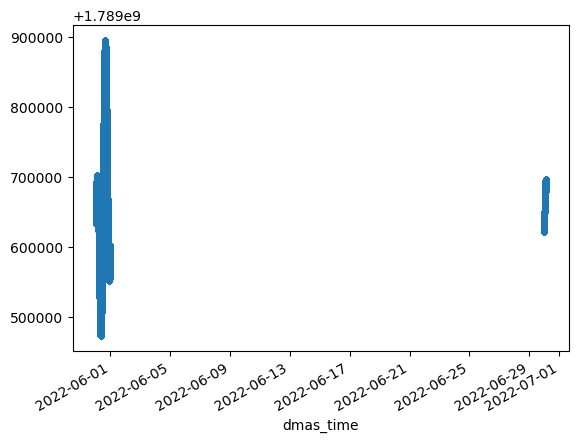

In [32]:
df['xFP'][0:100000].plot(marker='.',linewidth=0)

### Optional: export calibrated data to CSV

In [14]:
# Uncomment to save the calibrated output
out_path = 'out/NCHR_calibrated_new.csv'
df[['ppc_time', 'T_Housing', 'T_SF', 'P_SF']].to_csv(out_path)
print(f'Saved to {out_path}')

Saved to out/NCHR_calibrated_new.csv
